In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.offline as pyo
import plotly.graph_objs as go
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder

In [ ]:
# my model
# from tables.file import parameters
# def sigmoid(z):
#   return 1 / (1 + np.exp(-z))

# def initialize_parameters(dim):
#   w = np.zeros((dim, 1))
#   b = 0
#   return w, b

# def propagate(X, y, w, b):
#     m = X.shape[1]
#     A = sigmoid(np.dot(w.T, X) + b)
#     cost = (-1/m) * np.sum(y.reshape(A.shape) * np.log(A) + (1-y.reshape(A.shape)) * np.log(1-A))
#     dw = (1/m) * np.dot(X, (A-y).T)
#     db = (1/m) * np.sum(A-y)
#     gradients = {"dw": dw, "db": db}
#     return gradients, cost

# def optimize(X, y, w, b, num_iterations, learning_rate):
#     costs = []

#     for i in range(num_iterations):
#         gradients, cost = propagate(X, y, w, b)
#         dw = gradients["dw"]
#         db = gradients["db"]

#         w -= learning_rate * dw
#         b -= learning_rate * db
#         if i % 100 == 0:
#             costs.append(cost)
#     parameters = {
#         "w": w,
#         "b": b
#     }
#     return parameters, costs

# def predict(X, w, b):
#     m = X.shape[1]
#     predictions = np.zeros((1, m))
#     A = sigmoid(np.dot(w.T, X) + b)
#     predictions[A > 0.5] = 1
#     return predictions

In [ ]:
train = pd.read_csv('train.csv')
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


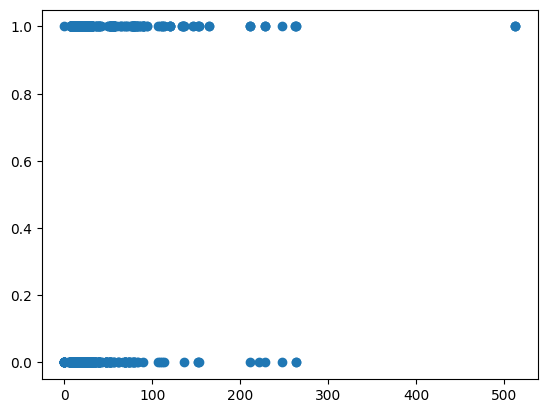

In [ ]:
train_dropped = train.drop(['Ticket', 'PassengerId', 'Name'], axis=1)
train_dropped.head()
plt.scatter(train['Fare'], train['Survived'])
plt.show()

In [ ]:
train_dropped.shape

(891, 9)

In [ ]:
print(train_dropped.isnull().sum())

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Cabin       687
Embarked      2
dtype: int64


In [ ]:
#train_dropped.head()
#train_dropped = train_dropped.drop(['Age', 'Cabin'], axis=1)
#Both the colums were dropped automatically due to excess null values
#this operation was performed by numpy's dropna() function

In [ ]:
male_sur = len(train_dropped[train_dropped.Sex == 'male'])
#fmale_sur = len(train_dropped[train_dropped.Sex == 'female'])
print(train_dropped.Survived.sum())
#print(len(train_dropped[train_dropped['Survived'] == 1]))
print(len(train_dropped[train_dropped['Survived'] == 0]))

342
549


In [ ]:
trace_0 = go.Box(y = train_dropped['Fare'], x = train_dropped['Survived'])
data = [trace_0]
layout = go.Layout()
fig = go.Figure(data, layout)
pyo.iplot(fig)

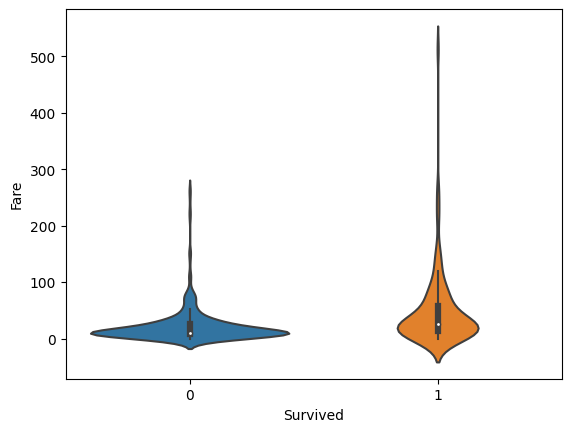

In [ ]:
sns.violinplot(x = train_dropped['Survived'], y = train_dropped['Fare'])
plt.xlabel('Survived')
plt.ylabel('Fare')
plt.show()

/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:3544: UserWarning:

58.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:3544: UserWarning:

28.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:3544: UserWarning:

68.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:3544: UserWarning:

41.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.



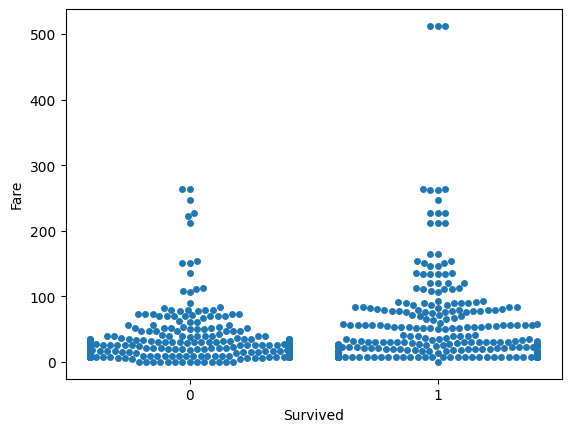

In [ ]:
sns.swarmplot(x = train_dropped['Survived'], y = train_dropped['Fare'])
plt.xlabel('Survived')
plt.ylabel('Fare')
plt.show()

<Axes: xlabel='Survived', ylabel='Fare'>

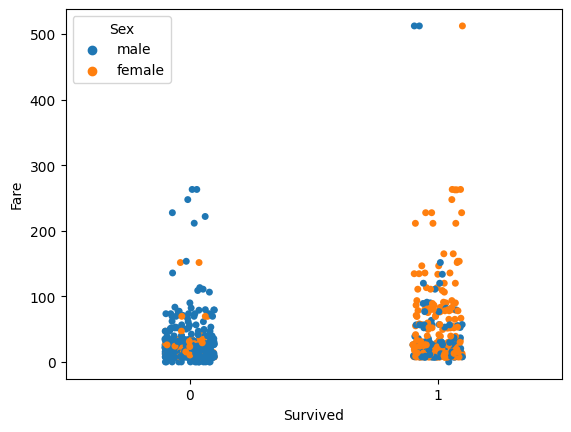

In [ ]:
sns.stripplot(data = train_dropped, x = train_dropped['Survived'], y = train_dropped['Fare'], hue = 'Sex')

In [ ]:
training = train[["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked", "Survived"]]
# training = training.dropna(subset = ['Age', 'Embarked'])
print(training.isnull().sum())
training.shape

Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
Survived      0
dtype: int64


(891, 8)

In [ ]:
pu = train.iloc[:, 5].values.reshape(-1, 1)
imputer = SimpleImputer(missing_values=np.nan, strategy="mean")
imputer = imputer.fit(pu)
pu = imputer.transform(pu)
pu = pd.DataFrame(pu)
pu.shape
training.shape

(891, 8)

In [ ]:
# print(len(training.iloc[:, 2]))

In [ ]:
training.iloc[:, 2] = pu.iloc[:, 0]
len(training["Age"]), len(pu)
print(training.isnull().sum())
# print(len(training.iloc[:, 2]))
# print(len(pu.iloc[:, 0]))

Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    2
Survived    0
dtype: int64


<ipython-input-240-ed0921c7a093>:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [ ]:
training = training.dropna(subset = ["Embarked"])
training["Embarked"]

0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: Embarked, Length: 889, dtype: object

In [ ]:
training["Embarked"].unique()

array(['S', 'C', 'Q'], dtype=object)

In [ ]:
replace_sex = {"male": 0, "female": 1}
replace_emb = {"S": 1, "C": 2, "Q": 3}

training["Sex"] = training["Sex"].map(replace_sex)
training["Embarked"] = training["Embarked"].map(replace_emb)
training["Embarked"]

0      1
1      2
2      1
3      1
4      1
      ..
886    1
887    1
888    1
889    2
890    3
Name: Embarked, Length: 889, dtype: int64

In [ ]:
training.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Survived
0,3,0,22.0,1,0,7.2500,1,0
1,1,1,38.0,1,0,71.2833,2,1
2,3,1,26.0,0,0,7.9250,1,1
3,1,1,35.0,1,0,53.1000,1,1
4,3,0,35.0,0,0,8.0500,1,0


In [ ]:
training_x = training.drop(["Survived"], axis = 1)
training_y = training["Survived"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(training_x, training_y, test_size = 0.2, random_state = 42)
X_train.shape

(711, 7)

In [ ]:
# X_train = train_data.drop(["Cabin"], axis=1)
# train_data.head()

In [ ]:
# X_train = X_train.T
# y_train = y_train.reshape(1, -1)
# w, b = initialize_parameters(X_train.shape[0])
# parameters, costs = optimize(X_train, y_train, w, b, num_iterations, learning_rate)
# w = parameters["w"]
# b = parameters["b"]

# num_features = X_train.shape[0]
# X_test = X_test.T
# predictions = predict(X_test, w, b)

# A_test = sigmoid(np.dot(w.T, X_test) + b)
# y_pred = (A_test > 0.5).astype(int)
# test_accuracy = accuracy_score(y_test, y_pred.reshape(-1))
# print("Test Accuracy:", test_accuracy)

In [ ]:
from datetime import datetime as dt
from sklearn.linear_model import LogisticRegression
start = dt.now()
logMod = LogisticRegression()
logMod = logMod.fit(X_train, y_train)
pred = logMod.predict(X_test)
end = dt.now()

In [ ]:
# X_train.shape

In [ ]:
print("Time taken:", (end - start))
print("Accuracy:", accuracy_score(y_test, pred))

Time taken: 0:00:00.023725
Accuracy: 0.7865168539325843


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(training_x, training_y, test_size=0.2, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)

Accuracy: 0.7865168539325843


In [ ]:
test_data = pd.read_csv("test.csv")
test_data = test_data[["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]]

replace_sex = {"male": 0, "female": 1}
replace_emb = {"S": 1, "C": 2, "Q": 3}

test_data["Sex"] = test_data["Sex"].map(replace_sex)
test_data["Embarked"] = test_data["Embarked"].map(replace_emb)
test_data["Embarked"]

imputer = SimpleImputer(strategy="mean")
test_data = pd.DataFrame(imputer.fit_transform(test_data), columns=test_data.columns)

# fare_imputer = SimpleImputer(missing_values=np.nan, strategy="mean")
# test_data["Fare"] = fare_imputer.fit_transform(test_data[["Fare"]])

# pu = test_data.iloc[:, 5].values.reshape(-1, 1)
# imputer = SimpleImputer(missing_values=np.nan, strategy="mean")
# imputer = imputer.fit(pu)
# pu = imputer.transform(pu)
# pu = pd.DataFrame(pu)
# test_data.iloc[:, 5] = pu.iloc[:, 0]

label_encoder = LabelEncoder()
test_data["Sex"] = label_encoder.fit_transform(test_data["Sex"])
test_data["Embarked"] = label_encoder.fit_transform(test_data["Embarked"])

missing_columns = set(X_train.columns) - set(test_data.columns)
for column in missing_columns:
    test_data[column] = 0

passenger_ids = test_data.index + 892

test_data = test_data[X_train.columns]

prediction = model.predict(test_data)
prediction = (prediction > 0.5).astype(int).ravel()

submit = pd.DataFrame({'PassengerId': passenger_ids, 'Survived': prediction})
submit.to_csv("final_submission.csv", index=False)

In [ ]:
test_data.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,1,34.5,0,0,7.8292,1
1,3,0,47.0,1,0,7.0000,2
2,2,1,62.0,0,0,9.6875,1
3,3,1,27.0,0,0,8.6625,2
4,3,0,22.0,1,1,12.2875,2


In [ ]:
X_train.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
708,1,1,22.000000,0,0,151.5500,1
240,3,1,29.699118,1,0,14.4542,2
382,3,0,32.000000,0,0,7.9250,1
792,3,1,29.699118,8,2,69.5500,1
683,3,0,14.000000,5,2,46.9000,1


In [ ]:
final_submit = pd.read_csv("final_submission.csv")
final_submit.head()
final_submit.shape

(418, 2)